# OpenCV
https://opencv.org/

![](https://opencv.org/wp-content/uploads/2022/04/logo.png)




OpenCV 공식 document
https://docs.opencv.org/master   (최신버젼)


OpenCV 공식 document (버젼별 다운로드)
https://docs.opencv.org/

OpenCV Python Tutorial
https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html

## OpenCV 설치
- pip install opencv-python
- pip install opencv-contrib-python   (← OpenCV 추가 모듈도 사용하려면 설치)


#### OpenCV 최신버젼 확인

- 2025.2 현재 4.13.0
- ※ v4.2 는 버그 있다

In [1]:
import cv2
print(cv2.__version__)

5.0.0


## OpenCV 프로그래밍 기초
> 아래 '영상' 이라 함은 이미지 를 의미.  이미지프로세싱 분야에서 '영상' 이란 보통 한장의 이미지를 의미함.   유튜브 같은 영상은 '동영상' 이라 함.

- 영상 불러와서 출력하기
- 영상 데이터 다루기 (생성, 복사, 크롭, 합성)
- 컬러 영상 처리 : 색 공간 변환
- 기하학적 변환 (크기 변환, 회전 변환)
- OpenCV 그리기 함수

## 카메라 & 동영상 처리
- 카메라 & 동영상 프레임 처리
- 동영상 파일 저장하기

### imread() 이미지 읽어오기

In [2]:
import os, sys
import matplotlib.pyplot as plt

In [3]:
base_path = r'/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision'

In [4]:
img = cv2.imread(os.path.join(base_path, 'cat.bmp'))
img

array([[[191, 190, 170],
        [199, 195, 176],
        [205, 201, 182],
        ...,
        [244, 242, 237],
        [244, 242, 237],
        [244, 242, 237]],

       [[193, 192, 172],
        [200, 196, 177],
        [207, 202, 183],
        ...,
        [244, 242, 237],
        [244, 242, 237],
        [244, 242, 237]],

       [[194, 192, 172],
        [200, 196, 177],
        [207, 203, 184],
        ...,
        [244, 242, 237],
        [244, 242, 237],
        [244, 242, 237]],

       ...,

       [[  0,  15,  28],
        [  0,  16,  29],
        [  2,  18,  30],
        ...,
        [  3,  10,  13],
        [  4,  11,  14],
        [  3,  10,  12]],

       [[  0,  17,  27],
        [  1,  17,  29],
        [  1,  17,  29],
        ...,
        [  2,  11,  12],
        [  3,  11,  13],
        [  2,  10,  13]],

       [[  0,  17,  27],
        [  0,  15,  27],
        [  0,  15,  27],
        ...,
        [  1,  12,  11],
        [  3,  11,  13],
        [  3,  10,  14]]

In [5]:
img.shape
# (480, 640, 3)
# (height, width, channel)
# (행,       열,  [b, g, r])   <-- ✨ r, g, b 가 아니라 b, g, r 이다!

(480, 640, 3)

In [6]:
img.dtype

dtype('uint8')

In [7]:
# imread() 가 읽어오지 못하면 None 리턴
if img is None:
    print('Image load failed!')
    

### imshow() 불러온 이미지 화면에 출력하기

In [8]:
cv2.namedWindow('image')  # 새로운 창을 만들고 창의 이름은 'image' (고유한 문자열로 주어야 한다)
cv2.imshow('image', img)

cv2.waitKey(0) # waitKey() 사용자 입력까지 기다림. 매개변수 0 이면 입력할때까지 무한 기다림.
                # ex) waitKey(2000) 2초동안 입력 기다림.

cv2.destroyAllWindows()   # 열려져 있는 모든 창을 닫음
for _ in range(5):  # macOS에서는 destroyAllWindows()만으로는 창이 안 닫히고, 뒤에 waitKey(1)을 몇 번 더 때려줘야 실제로 사라짐
    cv2.waitKey(1)

# ↓ 아래와 같이 창이 뜨면.  창을 닫을때 [X] 닫기 버튼을 눌러도 되긴 하나

In [9]:
img = cv2.imread(os.path.join(base_path, 'cat.bmp'), cv2.IMREAD_GRAYSCALE)
print(img.shape) # (480, 640)
cv2.namedWindow('image')
cv2.imshow('image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)

(480, 640)


In [10]:
# 키보드의 특정 key 가 입력될때 창 닫기

img = cv2.imread(os.path.join(base_path, 'cat.bmp'), cv2.IMREAD_GRAYSCALE)
cv2.imshow('image', img)
while True:
    if cv2.waitKey(0) == 27:   # ESC키가 눌리면 창 닫기
        break
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)


## matplotlib 을 이용한 영상 출력

- 컬러 영상 출력
    - matplotlib 은 색상정보가 **RGB 순서** 이어야 함
    - 반면 OpenCV 에서 읽어온 영상의 색상정보는 **BGR 순서** 다
    - 따라서, matplotlib 으로 출력하려면 cv2.cvtColor() 함수를 사용해야 한다

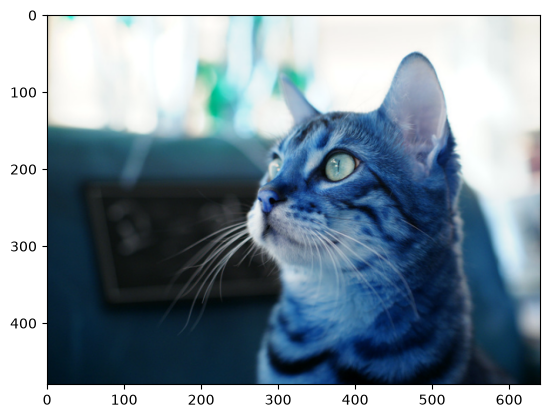

In [11]:
img = cv2.imread(os.path.join(base_path, 'cat.bmp'))
plt.imshow(img)  # 그냥 출력하면 B 채널과 R 채널이 바뀌어 출력.
plt.show()  # 

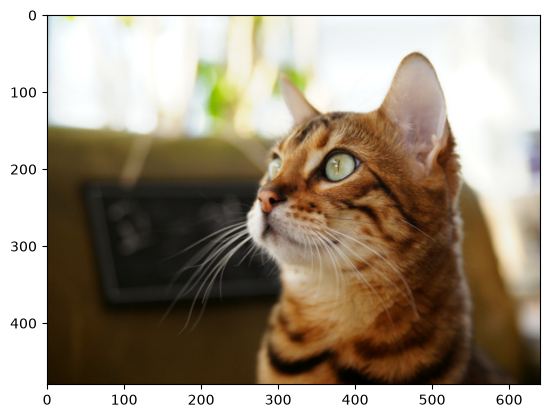

In [12]:
# BGR -> RGB 변환
conv_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(conv_img)
plt.show()

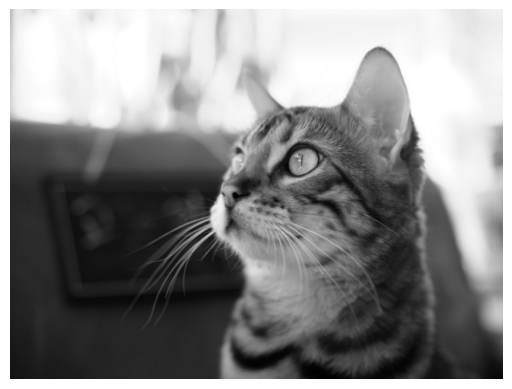

In [13]:
# gray scale 변환
conv_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(conv_img, cmap='gray')
plt.axis('off')
plt.show()

## 카메라 & 동영상 처리

In [14]:
# VideoCapture 클래스
# OpenCV에서는 카메라와 동영상으로부터 프레임(frame)을 받아오는  작업을 
# cv2.VideoCapture 클래스 하나로 처리함

# 동영상파일, 혹은 카메라로부턴 동영상을 처리한다는 것은
# 결국 한장의 영상(이미지, 프레임)씩 가져와서 한장씩 처리 하며, 이를 반복하는 것이다.


# 기본적으로 '동영상 파일' 에서 읽어오는 것과 '카메라' 에서 가져오는 것은 다르다
# 그러나, read() 를 사용해서 한장씩 읽어와서 화면에 보여주면 동영상처럼 보여지게 된다.

# VideoCapture() 하나를 가지고 '동영상' 과 '카메라' 두가지를 다룰수 있다.

#     VideoCapture(index)  # index 는 카메라 device 번호(정수), - 0 이면 기본 카메라
#     VideoCapture(filename)   # 생성자.


### 카메라 사용하기

In [15]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print('camera 사용 불가')
    sys.exit()

while True:
    # open 되어 있는 카메라에서 한 프레임씩 가져오기
    ret, frame = cap.read()
    # 정상적으로 이미지 가져오면 ret 값은 True, 
    # 실패하면 ret 값은 False, frame 은 None    

    if not ret:
        break

    cv2.imshow('frame', frame)
    if cv2.waitKey() == 27:
        break

cap.release()
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)

### 동영상으로 보이게 하기

In [16]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print('camera 사용 불가')
    sys.exit()

# 카메라, 비디오 장치 속성값 읽기
print("Frame width: ", round(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Frame height: ", round(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

while True:
    # open 되어 있는 카메라에서 한 프레임씩 가져오기
    ret, frame = cap.read()
    # 정상적으로 이미지 가져오면 ret 값은 True, 
    # 실패하면 ret 값은 False, frame 은 None    

    if not ret:
        break

    cv2.imshow('frame', frame)
    if cv2.waitKey(1) == 27:   # 일정시간 (1ms) 기다린후 다음 프레임 처리.
        break

cap.release()
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)

Frame width:  1920
Frame height:  1080


### 파일로부터 동영상 읽어오기

In [17]:
cap = cv2.VideoCapture(os.path.join(base_path, 'vtest.avi')) # 동영상 파일

if not cap.isOpened():
    print('camera 사용 불가')
    sys.exit()


while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow('frame', frame)
    if cv2.waitKey(30) == 27:  # 적당한 속도를 주면. 재생 속도 조정된다.
                            # 사실 동영상 파일은 자신만의 fps (frame per second) 가 존재한다
                            # 몇 ms 단위로 출력할지 설정되어 있다.
                            # 그러나, OpenCV 로 동영상 재생 프로그램 만드는 용도가 아니라면
                            # 걍 짧게 값을 주어도 된다.
        break

cap.release()
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)

###  영상 처리 알고리즘 적용 예
동영상에서 한장한장 뽑아낸 영상(frame) 에 여러가지 이미지 프로세싱 가능
- OpenCV 는 다양한 기능(알고리즘) 제공
- OpenCV 에서 제공하는 edge 검출 알고리즘 사용해보기

In [39]:
# cap = cv2.VideoCapture(os.path.join(base_path, 'vtest.avi')) # 동영상 파일
cap = cv2.VideoCapture(0)  # 카메라

if not cap.isOpened():
    print('camera 사용 불가')
    sys.exit()


while True:
    ret, frame = cap.read()

    if not ret:
        break

    edge = cv2.Canny(frame, 50, 150)  # edge 검출
    
    
    cv2.imshow('frame', frame)
    cv2.imshow('edge', edge)
    if cv2.waitKey(30) == 27: 
        break

cap.release()
cv2.destroyAllWindows()

for _ in range(5):
    cv2.waitKey(1)

### 동영상 파일 저장하기

In [19]:
# cap = cv2.VideoCapture(os.path.join(base_path, 'vtest.avi')) # 동영상 파일
cap = cv2.VideoCapture(0)  # 카메라

if not cap.isOpened():
    print('camera 사용 불가')
    sys.exit()

# 동영상 저장을 위한 cv2.VideoWriter 객체 생성
w = round(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = round(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)  # frame per second 정보
fourcc = cv2.VideoWriter_fourcc(*'DIVX')  # Video 출력 포맷 (*'DIVX') -> ('D', 'I', 'V', 'X')
out = cv2.VideoWriter(os.path.join(base_path, 'out', 'output.avi'), fourcc, fps, (w, h))

while True:
    ret, frame = cap.read()

    if not ret:
        break

    edge = cv2.Canny(frame, 50, 150)  # edge 검출
    edge = cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)
    out.write(edge)

    cv2.imshow('frame', frame)
    cv2.imshow('edge', edge)
    if cv2.waitKey(30) == 27: 
        break
# 자원해제
cap.release()
out.release()
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)

# 한글 파일 이슈
Windows 사용자

- Python 에서 OpenCV 사용시 한글(utf-8) 을 처리하지 못하는 문제 발생.
- 파일 경로에 한글이 있어도 읽기/쓰기 시 문제 발생
- **imencode()** 함수를 사용하여 우회 해결


In [20]:
file_name = '강아지.jpg'  # 한글 이름
img = cv2.imread(os.path.join(base_path, file_name))
cv2.imshow('image', img)

while True:
    if cv2.waitKey(0) == 27:
        break
        
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)

In [21]:
# imread() 함수 정의
import numpy as np

def imread(filename, flags=cv2.IMREAD_COLOR, dtype=np.uint8):
    try:
        n = np.fromfile(filename, dtype)  # 일단 numpy로 읽어들임
        img = cv2.imdecode(n, flags)
        return img
    except Exception as e:
        print(e)
        return None
    

In [22]:
# imwrite() 함수 정의
def imwrite(filename, img, params=None):
    try:
        ext = os.path.splitext(filename)[1]  # 확장자
        result, n = cv2.imencode(ext, img, parmas)  # -> success(True/False), encoded (1차원 배역)
    
        if result:
            with open(filename, 'w+b') as f:
                n.tofile(f)
            return True
        else:
            return False
    except Exception as e:
        print(e)
        return None
        

In [23]:
file_name = '강아지.jpg'  # 한글 이름
img = imread(os.path.join(base_path, file_name))
cv2.imshow('image', img)

while True:
    if cv2.waitKey(0) == 27:
        break
        
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)

In [24]:
file_name = '강아지gray.jpg'  # 한글이름
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2.imwrite(os.path.join(base_path, 'out', file_name), gray_img)

True

In [25]:
imwrite(os.path.join(base_path, 'out', file_name), gray_img)

name 'parmas' is not defined


# OpenCV 로 한글 출력
OpenCV를 이용하면서 한글이 깨진다


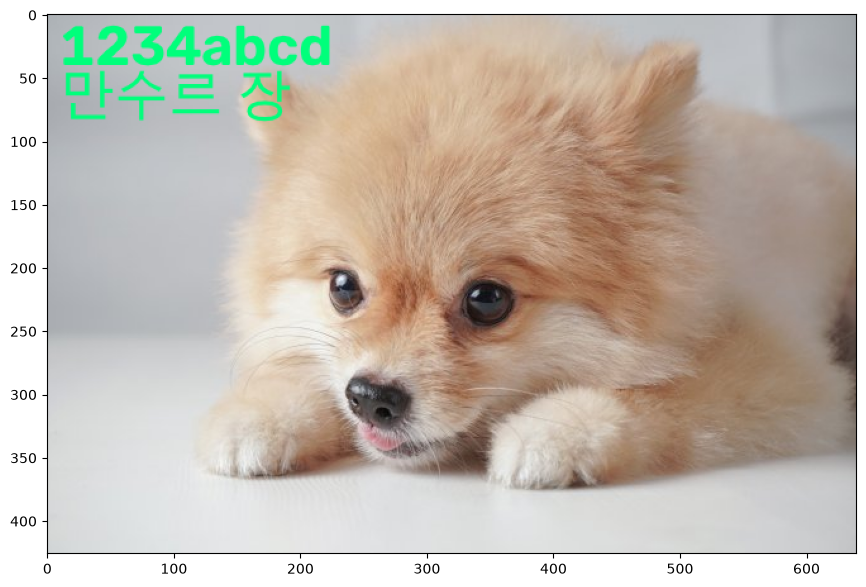

In [26]:
img_copy = img.copy() 

# 글자출력
cv2.putText(
    img_copy, 
    '1234abcd',
    org=(10, 40),  # (x, y) 를 base 로 하여 출력
    fontFace = cv2.FONT_HERSHEY_SIMPLEX,  # 글꼴
    fontScale = 1.5,
    color = (123, 255, 0),   # (B, G, R)
    thickness = 2,  # 굵기
)

cv2.putText(
    img_copy, 
    '만수르 장',  # 한글
    org=(10, 80),  # (x, y) 를 base 로 하여 출력
    fontFace = cv2.FONT_HERSHEY_SIMPLEX,  # 글꼴
    fontScale = 1.5,
    color = (123, 255, 0),   # (B, G, R)
    thickness = 2,  # 굵기
)

conv_img = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,7))
plt.imshow(conv_img)
plt.show()



In [27]:
# OpenCV를 이용하면서 한글이 깨지기 때문에
# PIL을 이용해 한글을 출력하면 된다.

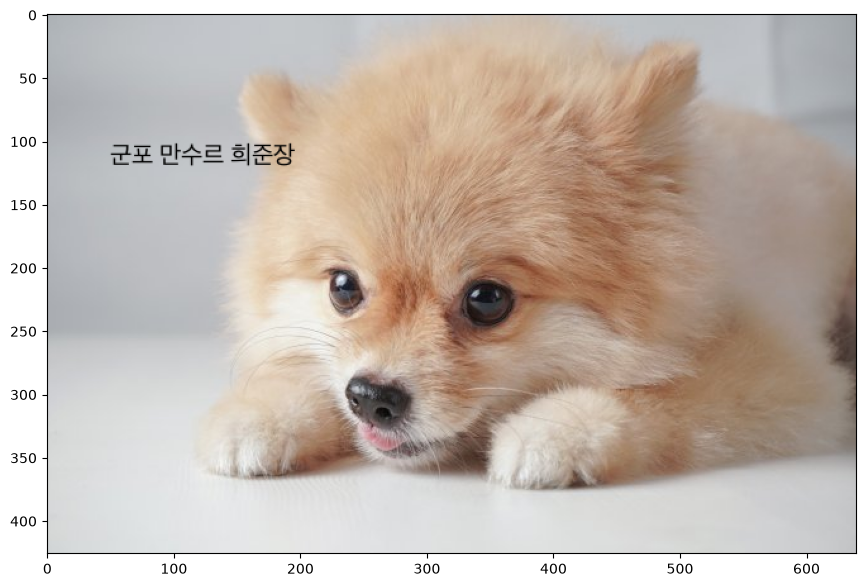

In [28]:
from PIL import ImageFont, ImageDraw, Image

img_data = img.copy() 

img_data = Image.fromarray(img_data)

draw = ImageDraw.Draw(img_data)
font = ImageFont.truetype('/System/Library/Fonts/AppleSDGothicNeo.ttc', 20)
org = (50, 100)
text = "군포 만수르 희준장"
draw.text(org, text, font=font, fill=(0, 0, 0))  # text 출력
img_data = np.array(img_data)   # 다시 OpenCV 가 처리 가능한 numpy 배열로 변환

conv_img = cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,7))
plt.imshow(conv_img)
plt.show()

